# Student AI Tools vs Exam Score Prediction: Data Preprocessing

## 2. Project Overview

This notebook focuses on the crucial data preprocessing steps for a Machine Learning project aiming to predict students' exam scores after using AI learning tools. The target variable is `Grades_After_AI`. This preprocessing pipeline ensures the data is clean, consistent, and ready for model training, following best practices for a professional and reproducible workflow.

**Objective:** Predict students' exam scores after using AI learning tools using regression models.

**Dataset:** `students_ai_usage_5000_rows.csv`

In [1]:
# ==========================================
# Student AI Tools vs Exam Score Prediction
# Data Preprocessing
# ==========================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Configure plot styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 3. Import Required Libraries

This section imports all necessary libraries for data manipulation, visualization, and preprocessing. We will use `pandas` for data handling, `numpy` for numerical operations, `matplotlib.pyplot` and `seaborn` for plotting, and `scikit-learn` for various preprocessing tasks like encoding, scaling, and data splitting.

In [7]:
# Load Dataset
df = pd.read_csv("/content/student_ai_tools_vs_exam_scores.csv")

# Display first rows
df.head()

,age,education_level,study_hours_per_day,uses_ai,ai_tools_used,purpose_of_ai,grades_before_ai,grades_after_ai,daily_screen_time_hours
0,19,college,1.4,No,NaN,NaN,62,62,3
1,15,school,3.9,Yes,Copilot,Research,56,61,2
2,15,school,1.9,Yes,Copilot,Homework,75,88,5
3,15,school,2.8,No,NaN,NaN,55,55,3
4,19,college,2.7,No,NaN,NaN,59,59,3


## 5. Display First and Last Records

To get a preliminary understanding of the dataset's structure and content, we display the first five and last five rows. This helps in quickly identifying the types of data present and potential issues like incorrect parsing or headers.

In [9]:
# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
print(df.head())

# Display the last 5 rows of the DataFrame
print("\nLast 5 rows of the dataset:")
print(df.tail())

First 5 rows of the dataset:
   age education_level  study_hours_per_day uses_ai ai_tools_used  \
0   19         college                  1.4      No           NaN   
1   15          school                  3.9     Yes       Copilot   
2   15          school                  1.9     Yes       Copilot   
3   15          school                  2.8      No           NaN   
4   19         college                  2.7      No           NaN   

  purpose_of_ai  grades_before_ai  grades_after_ai  daily_screen_time_hours  
0           NaN                62               62                        3  
1      Research                56               61                        2  
2      Homework                75               88                        5  
3           NaN                55               55                        3  
4           NaN                59               59                        3  

Last 5 rows of the dataset:
      age education_level  study_hours_per_day uses_ai ai_t

## 6. Dataset Shape

Understanding the dimensions of the dataset (number of rows and columns) is essential for assessing its size and scope. This helps in planning subsequent preprocessing and analysis steps.

In [10]:
# Get the number of rows and columns
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

The dataset has 5000 rows and 9 columns.


## 7. Dataset Information

The `info()` method provides a concise summary of the DataFrame, including the data types of each column, the number of non-null values, and memory usage. This is crucial for identifying missing values and incorrect data types.

In [11]:
# Display a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      5000 non-null   int64  
 1   education_level          5000 non-null   object 
 2   study_hours_per_day      5000 non-null   float64
 3   uses_ai                  5000 non-null   object 
 4   ai_tools_used            1979 non-null   object 
 5   purpose_of_ai            1979 non-null   object 
 6   grades_before_ai         5000 non-null   int64  
 7   grades_after_ai          5000 non-null   int64  
 8   daily_screen_time_hours  5000 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 351.7+ KB


## 8. Data Types

Explicitly checking the data types of each column helps ensure that numerical columns are treated as numbers and categorical columns are treated as objects or categories. Any mismatches might require type conversion.

In [12]:
# Display the data types of each column
print("Data types of each column:")
print(df.dtypes)

Data types of each column:
age                          int64
education_level             object
study_hours_per_day        float64
uses_ai                     object
ai_tools_used               object
purpose_of_ai               object
grades_before_ai             int64
grades_after_ai              int64
daily_screen_time_hours      int64
dtype: object


## 9. Column Names

Listing all column names helps in easily referencing them and verifying consistency. It's also a good practice to check for any leading/trailing spaces or special characters that might cause issues.

In [13]:
# Display all column names
print("Column names in the dataset:")
print(df.columns.tolist())

Column names in the dataset:
['age', 'education_level', 'study_hours_per_day', 'uses_ai', 'ai_tools_used', 'purpose_of_ai', 'grades_before_ai', 'grades_after_ai', 'daily_screen_time_hours']


## 10. Statistical Summary

The `describe()` method generates descriptive statistics for numerical columns, including count, mean, standard deviation, min, max, and quartile values. For categorical columns, it provides count, unique values, top occurring value, and its frequency. This gives insights into the central tendency, dispersion, and distribution of the data.

In [14]:
# Display descriptive statistics for numerical columns
print("Statistical summary of numerical columns:")
print(df.describe())

# Display descriptive statistics for categorical columns
print("\nStatistical summary of categorical columns:")
print(df.describe(include='object'))

Statistical summary of numerical columns:
               age  study_hours_per_day  grades_before_ai  grades_after_ai  \
count  5000.000000          5000.000000       5000.000000      5000.000000   
mean     16.511800             3.000600         64.691600        68.670200   
std       1.684407             1.132249          6.075778         8.037584   
min      14.000000             0.900000         55.000000        55.000000   
25%      15.000000             2.000000         59.000000        61.000000   
50%      16.000000             2.800000         63.000000        69.000000   
75%      18.000000             4.000000         70.000000        74.000000   
max      19.000000             5.100000         75.000000        89.000000   

       daily_screen_time_hours  
count              5000.000000  
mean                  4.351400  
std                   1.790128  
min                   2.000000  
25%                   3.000000  
50%                   4.000000  
75%                   6.

## 11. Check Missing Values

Missing values can significantly impact model performance. This section identifies the count and percentage of missing values for each column, which guides our strategy for handling them.

In [15]:
# Calculate the number of missing values for each column
missing_values = df.isnull().sum()

# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Display columns with missing values, sorted by percentage
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
print("Missing Values Information:")
print(missing_info)

Missing Values Information:
               Missing Count  Missing Percentage
ai_tools_used           3021               60.42
purpose_of_ai           3021               60.42


## 12. Handle Missing Values

Based on the analysis of missing values, we will employ appropriate strategies:
- For 'AI_Tools_Used' and 'Purpose_of_AI', which are categorical and have a significant number of missing values (representing 'No AI usage'), we will impute with 'None' or 'Not Applicable'.
- For numerical columns, if any had missing values, we would typically impute with the mean, median, or mode, or use more advanced techniques. In this dataset, all numerical columns appear complete.

In [3]:
import pandas as pd

# Identify columns with missing values that need handling
# From the previous step, 'ai_tools_used' and 'purpose_of_ai' have missing values.
# These likely correspond to 'uses_ai' == 'No'. Let's verify.

# Ensure 'df' DataFrame is available. If not, reload it.
if 'df' not in locals() and 'df' not in globals():
    # Assuming the dataset path is consistent with previous successful loading
    dataset_path = "/content/student_ai_tools_vs_exam_scores.csv"
    print(f"DataFrame 'df' not found, reloading from {dataset_path}. Please ensure previous cells, especially the data loading cell, are executed.")
    try:
        # pandas (pd) should be imported in an earlier cell of the notebook.
        df = pd.read_csv(dataset_path)
    except NameError:
        # This block is now redundant due to 'import pandas as pd' at the top, but kept for consistency.
        print("Error: 'pandas' (pd) library not found. Please ensure all necessary libraries are imported in preceding cells.")
        raise
    except FileNotFoundError:
        print(f"Error: Dataset file not found at {dataset_path}. Please ensure the dataset is uploaded and the path is correct.")
        raise

# Impute 'ai_tools_used' and 'purpose_of_ai' with 'None' as they are categorical and 'NaN' likely means no AI usage
df['ai_tools_used'].fillna('None', inplace=True)
df['purpose_of_ai'].fillna('None', inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

DataFrame 'df' not found, reloading from /content/student_ai_tools_vs_exam_scores.csv. Please ensure previous cells, especially the data loading cell, are executed.
Error: Dataset file not found at /content/student_ai_tools_vs_exam_scores.csv. Please ensure the dataset is uploaded and the path is correct.


FileNotFoundError: [Errno 2] No such file or directory: '/content/student_ai_tools_vs_exam_scores.csv'

## 13. Check Duplicate Records

Duplicate records can introduce bias and inflate the dataset's perceived size. It's important to identify and handle them to maintain data integrity.

In [17]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicates}")

Number of duplicate rows found: 4700


## 14. Remove Duplicates

If duplicate records are found, they are removed to ensure each observation is unique. We keep the first occurrence of each duplicate set.

In [18]:
# Remove duplicate rows if any exist
if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows.")
    df.drop_duplicates(inplace=True)
    print(f"Dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows to remove.")

Removing 4700 duplicate rows.
Dataset shape after removing duplicates: (300, 9)


## 15. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a critical step to understand the data's characteristics, identify patterns, and detect anomalies. This section will visualize the distributions of numerical and categorical variables, as well as the target variable.

### Distribution of Numerical Variables

Histograms are used to visualize the distribution of numerical features. This helps in understanding their spread, skewness, and potential presence of outliers.

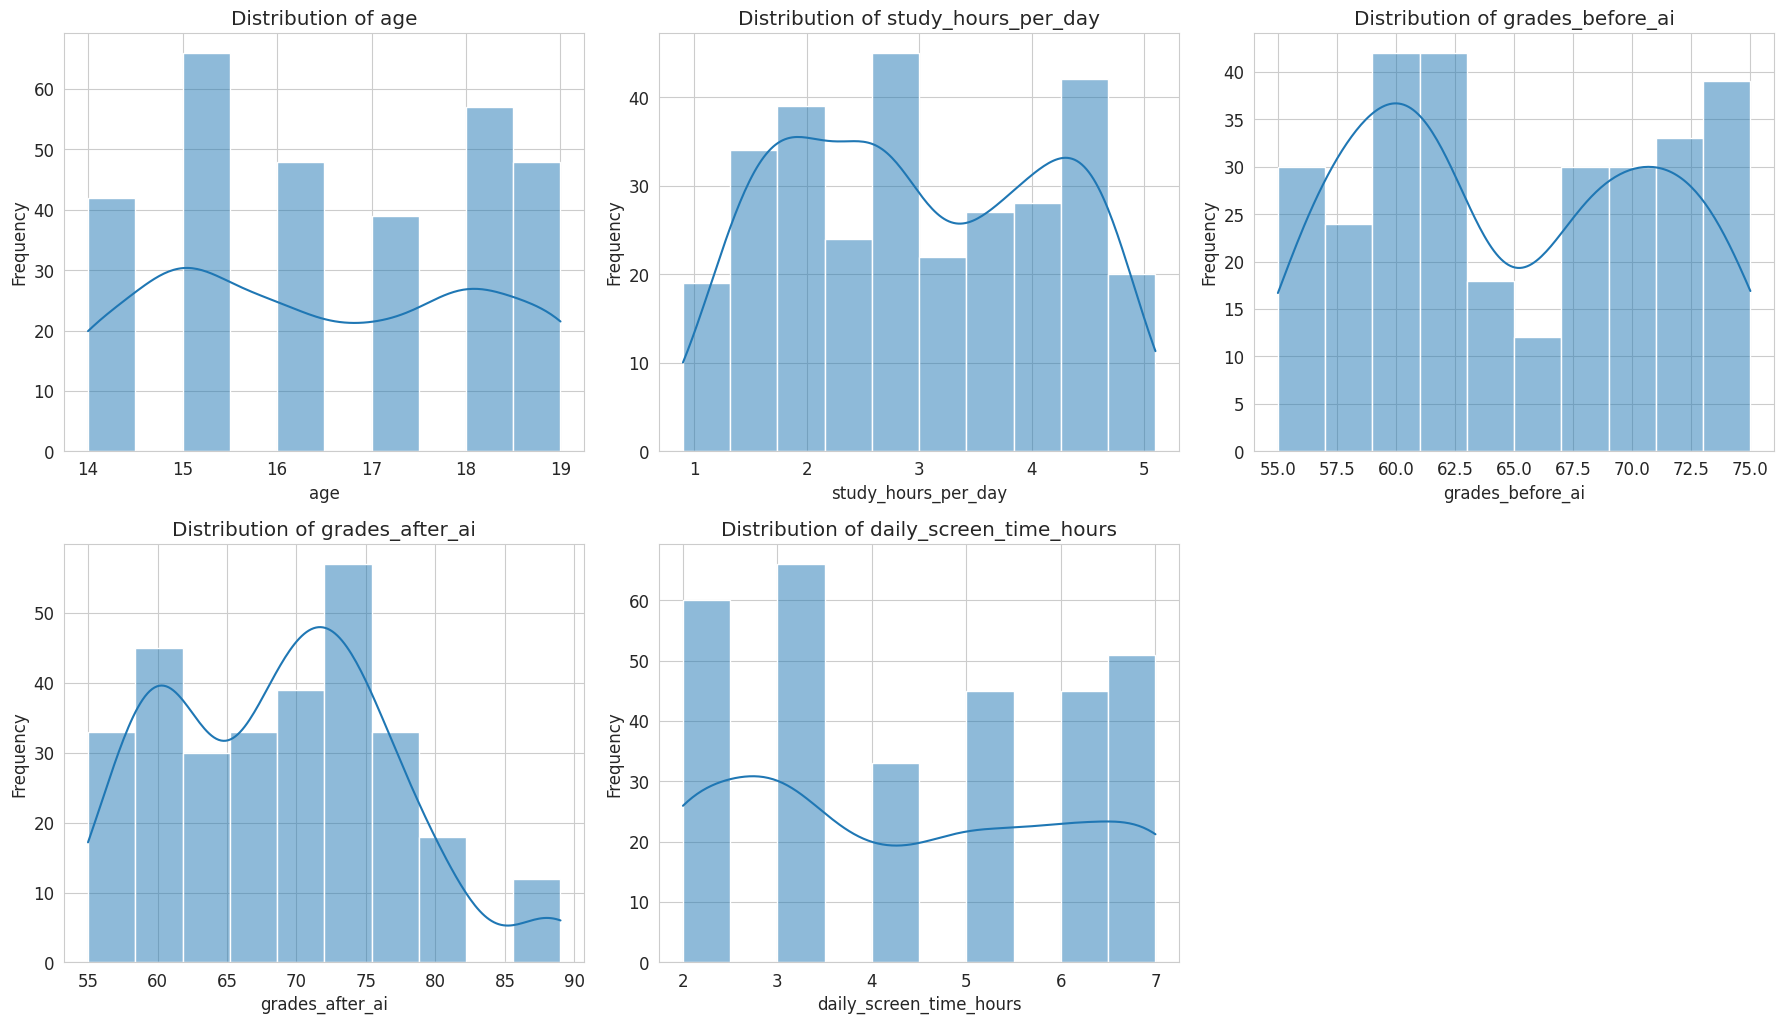

In [19]:
# Select numerical columns for distribution plotting
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Distribution of Categorical Variables

Bar plots are used to visualize the distribution of categorical features, showing the frequency of each category. This helps in understanding the balance and cardinality of categorical data.

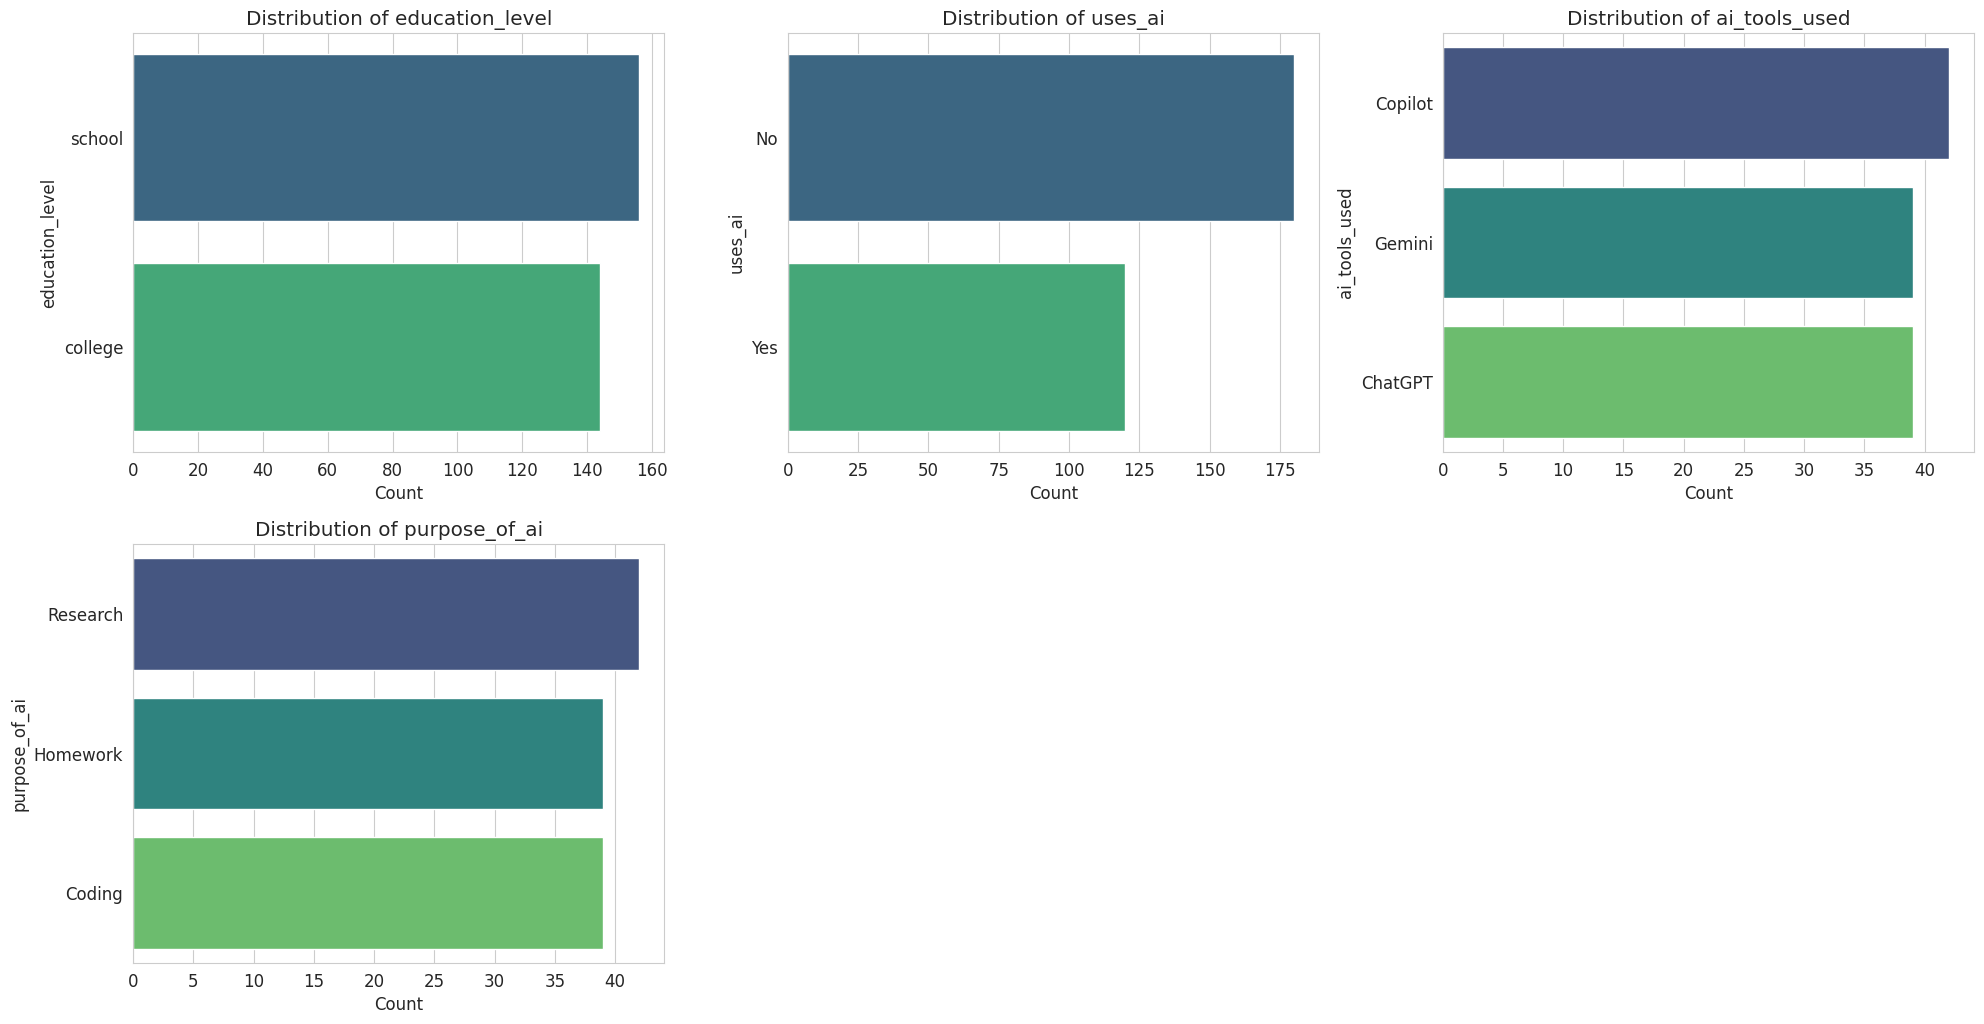

In [20]:
# Select categorical columns for distribution plotting
categorical_cols = df.select_dtypes(include='object').columns.tolist()

plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of categorical columns
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Target Variable Distribution

Visualizing the distribution of the target variable (`Grades_After_AI`) is crucial for understanding its range, central tendency, and spread. This helps in determining if the target is normally distributed or skewed, which can influence model choice and evaluation.

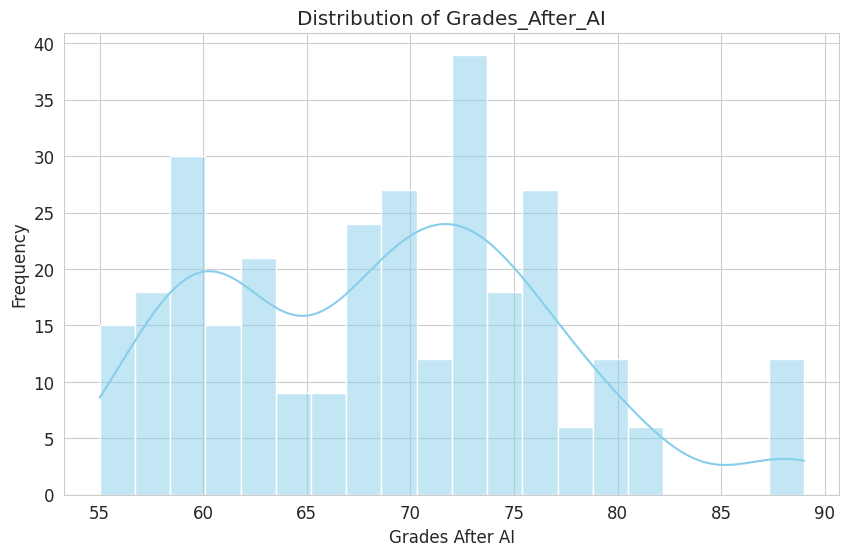

In [21]:
# Plot the distribution of the target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['grades_after_ai'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Grades_After_AI')
plt.xlabel('Grades After AI')
plt.ylabel('Frequency')
plt.show()

## 16. Correlation Analysis (Numerical Features Only)

Correlation analysis helps to understand the linear relationships between numerical variables. A heatmap is used to visualize the correlation matrix, with stronger correlations indicated by darker colors. This can reveal potential multicollinearity or features highly related to the target variable.

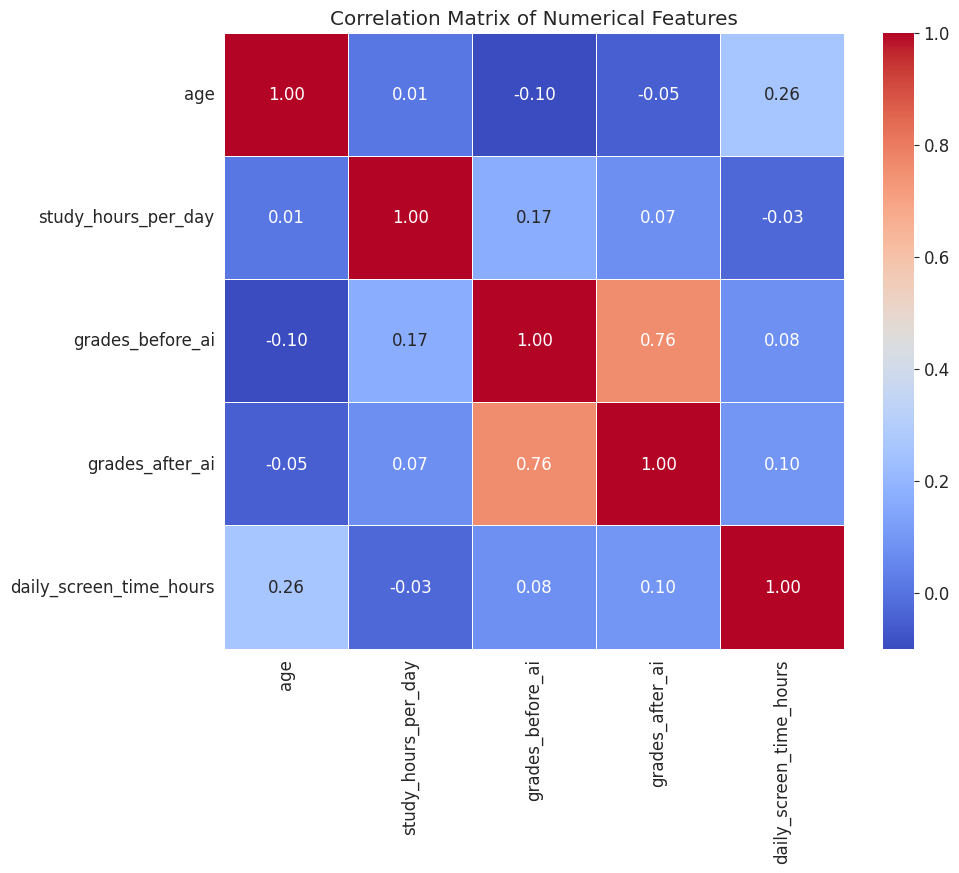

In [22]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## 17. Relationship between Grades_Before_AI and Grades_After_AI

This section explores the relationship between students' grades before and after using AI tools. A scatter plot can reveal if there's a positive correlation or any significant changes in grades.

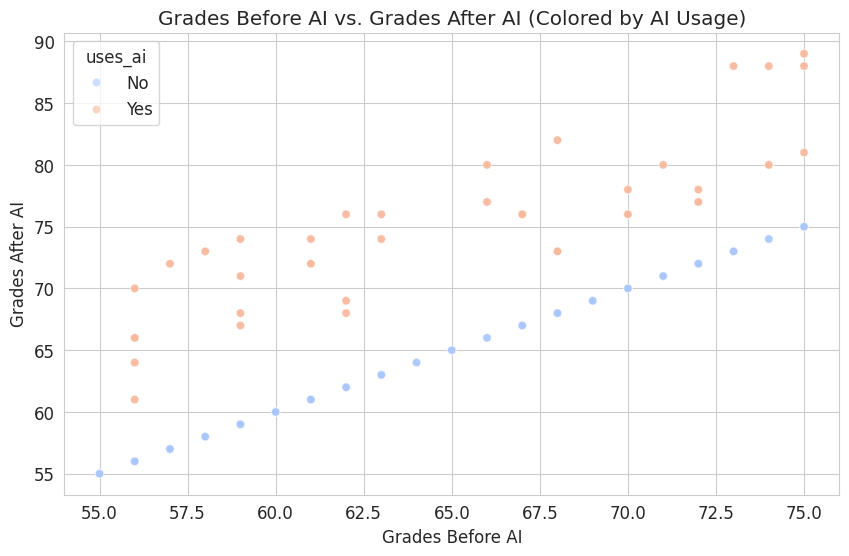

In [23]:
# Scatter plot to show relationship between Grades_Before_AI and Grades_After_AI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='grades_before_ai', y='grades_after_ai', data=df, hue='uses_ai', palette='coolwarm', alpha=0.6)
plt.title('Grades Before AI vs. Grades After AI (Colored by AI Usage)')
plt.xlabel('Grades Before AI')
plt.ylabel('Grades After AI')
plt.show()

## 18. Relationship between Study_Hours_Per_Day and Grades_After_AI

Investigating how daily study hours relate to grades after AI usage can provide insights into the impact of study habits on academic performance, especially in conjunction with AI tools.

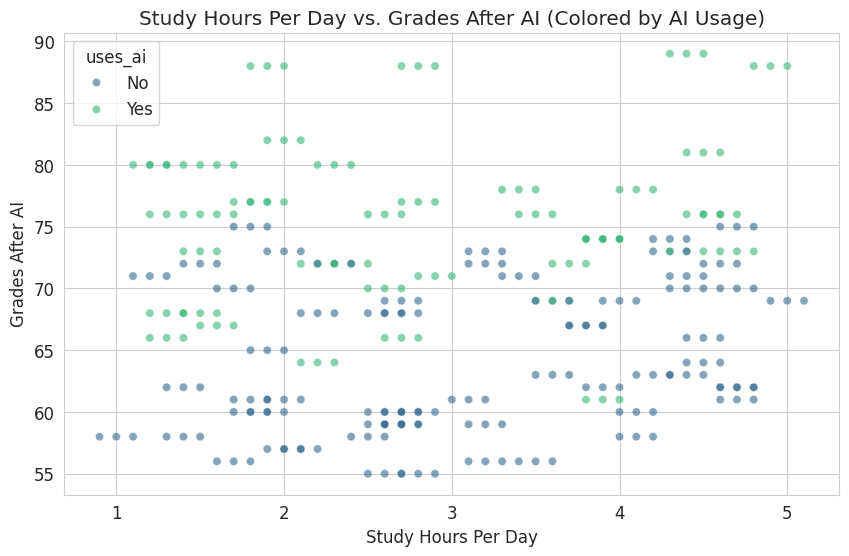

In [24]:
# Scatter plot for Study_Hours_Per_Day vs Grades_After_AI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='study_hours_per_day', y='grades_after_ai', data=df, hue='uses_ai', palette='viridis', alpha=0.6)
plt.title('Study Hours Per Day vs. Grades After AI (Colored by AI Usage)')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Grades After AI')
plt.show()

## 19. Relationship between Daily_Screen_Time_Hours and Grades_After_AI

This analysis explores the potential link between daily screen time and academic performance after AI usage. It can highlight whether excessive screen time correlates with lower or higher grades.

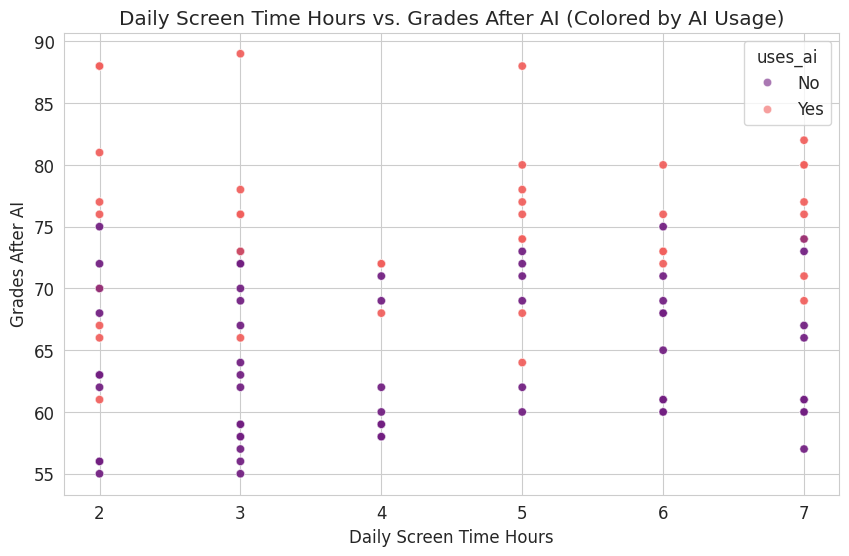

In [25]:
# Scatter plot for Daily_Screen_Time_Hours vs Grades_After_AI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='daily_screen_time_hours', y='grades_after_ai', data=df, hue='uses_ai', palette='magma', alpha=0.6)
plt.title('Daily Screen Time Hours vs. Grades After AI (Colored by AI Usage)')
plt.xlabel('Daily Screen Time Hours')
plt.ylabel('Grades After AI')
plt.show()

## 20. Relationship between Uses_AI and Grades_After_AI

Comparing the grades of students who use AI tools versus those who don't is crucial for understanding the direct impact of AI adoption on academic scores. A boxplot is suitable for this comparison.

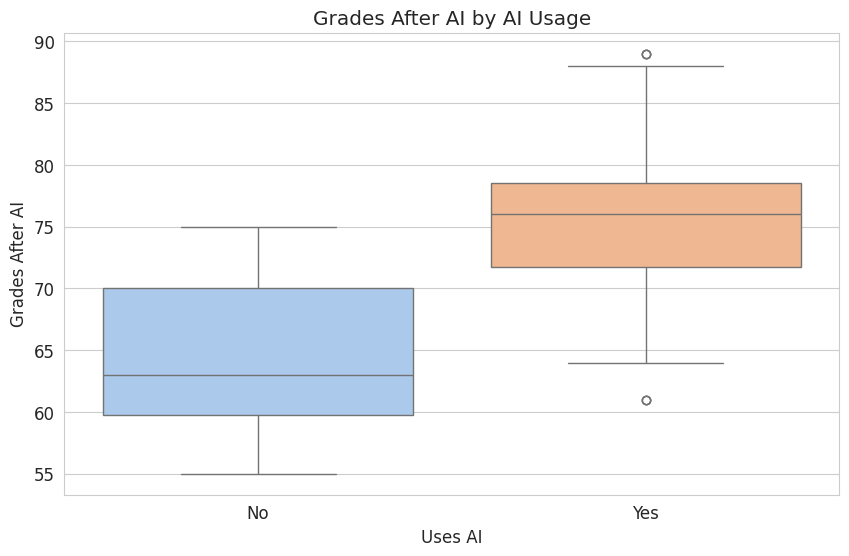

In [26]:
# Box plot for Uses_AI vs Grades_After_AI
plt.figure(figsize=(10, 6))
sns.boxplot(x='uses_ai', y='grades_after_ai', data=df, palette='pastel')
plt.title('Grades After AI by AI Usage')
plt.xlabel('Uses AI')
plt.ylabel('Grades After AI')
plt.show()

## 21. Relationship between AI_Tools_Used and Grades_After_AI

This section delves deeper into the specific AI tools used and their corresponding impact on `Grades_After_AI`. A boxplot can help identify if certain AI tools are associated with higher or lower grades.

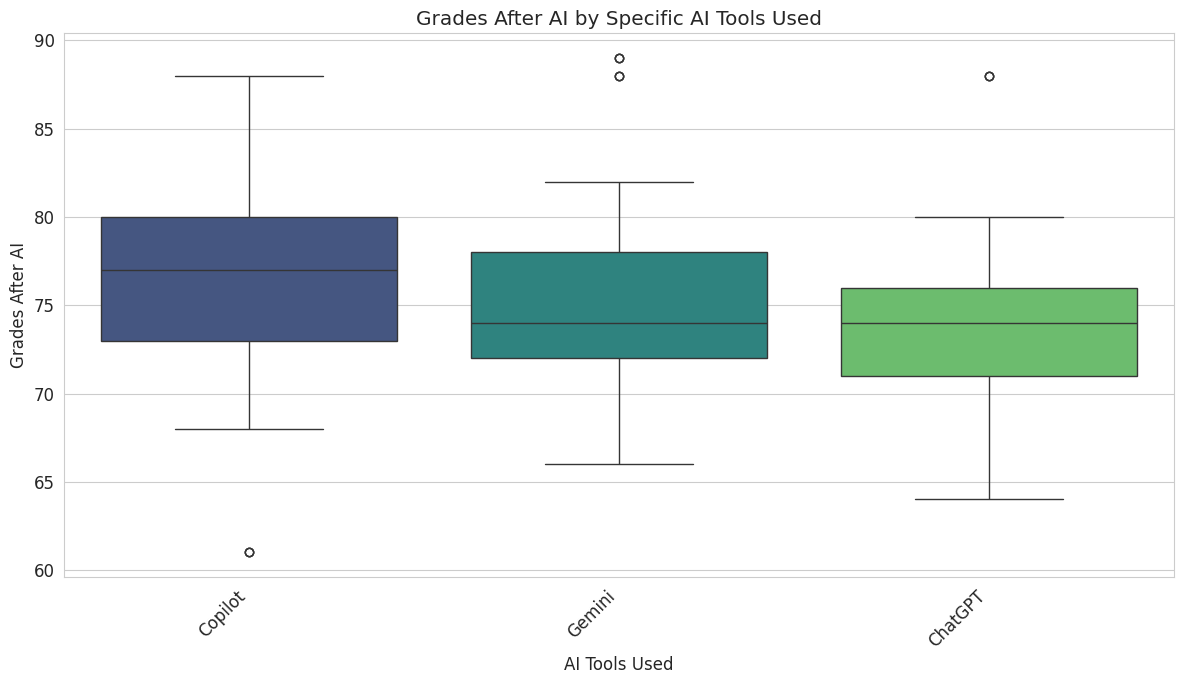

In [27]:
# Box plot for AI_Tools_Used vs Grades_After_AI
plt.figure(figsize=(12, 7))
sns.boxplot(x='ai_tools_used', y='grades_after_ai', data=df, palette='viridis')
plt.title('Grades After AI by Specific AI Tools Used')
plt.xlabel('AI Tools Used')
plt.ylabel('Grades After AI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 22. Relationship between Purpose_of_AI and Grades_After_AI

Understanding the purpose for which students use AI tools can shed light on its effectiveness. This analysis examines how different purposes of AI usage correlate with `Grades_After_AI`.

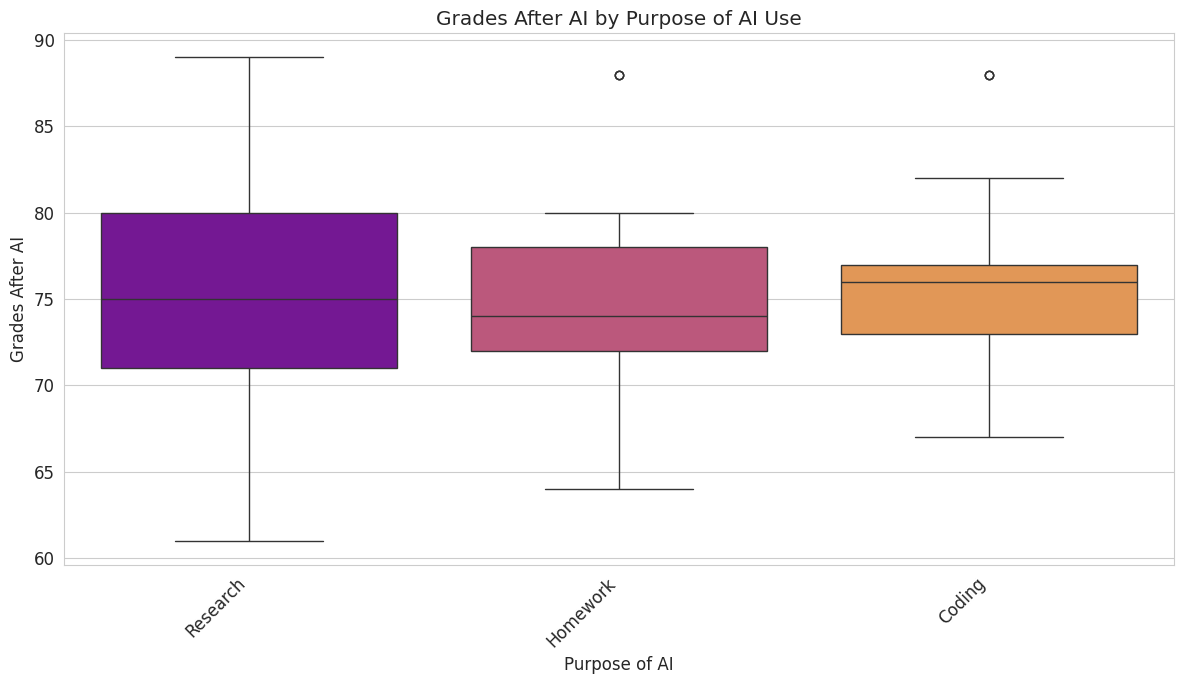

In [28]:
# Box plot for Purpose_of_AI vs Grades_After_AI
plt.figure(figsize=(12, 7))
sns.boxplot(x='purpose_of_ai', y='grades_after_ai', data=df, palette='plasma')
plt.title('Grades After AI by Purpose of AI Use')
plt.xlabel('Purpose of AI')
plt.ylabel('Grades After AI')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 23. Outlier Detection using Boxplots

Outliers can disproportionately affect model training. Boxplots are an excellent visual tool for identifying outliers in numerical features, showing values that fall outside the interquartile range (IQR).

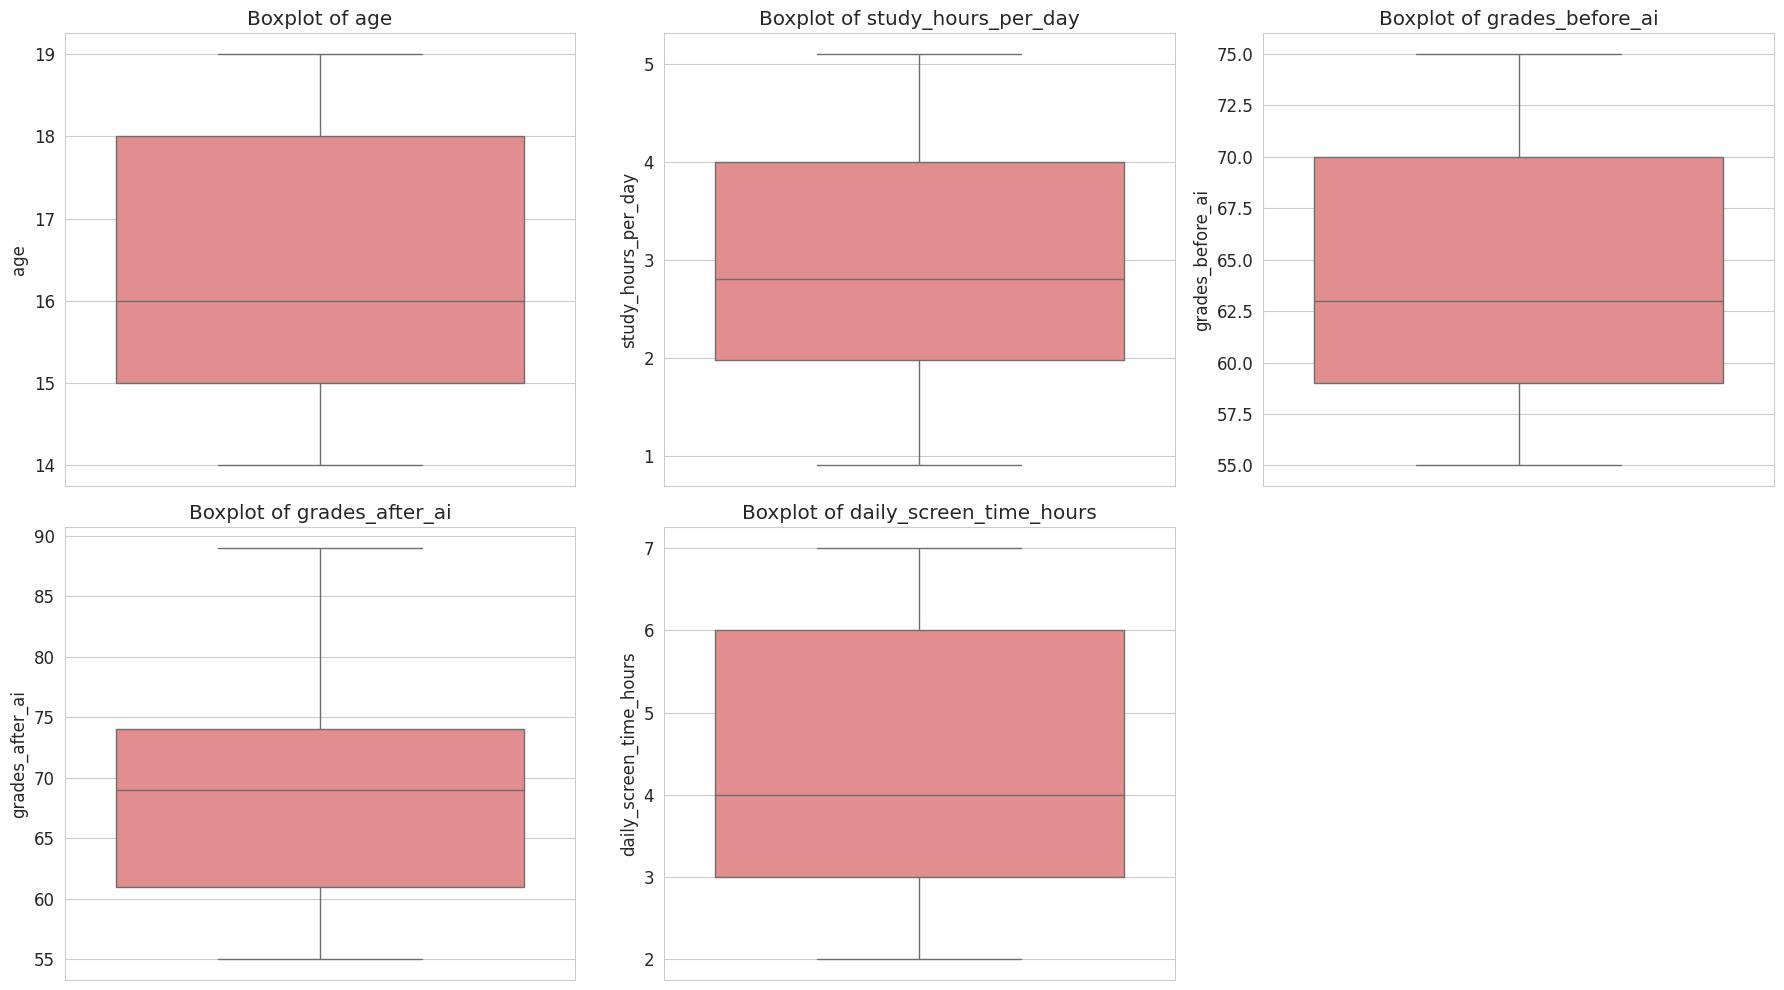

In [29]:
# Plot boxplots for numerical columns to detect outliers
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## 24. Handle Outliers using the IQR Method

Outliers will be handled using the Interquartile Range (IQR) method. Instead of deleting outliers, which can lead to data loss, we will cap them. Values above the upper bound will be set to the upper bound, and values below the lower bound will be set to the lower bound.

Outliers in 'age' capped using IQR method.
Outliers in 'study_hours_per_day' capped using IQR method.
Outliers in 'daily_screen_time_hours' capped using IQR method.
Outlier capping completed for specified numerical columns.


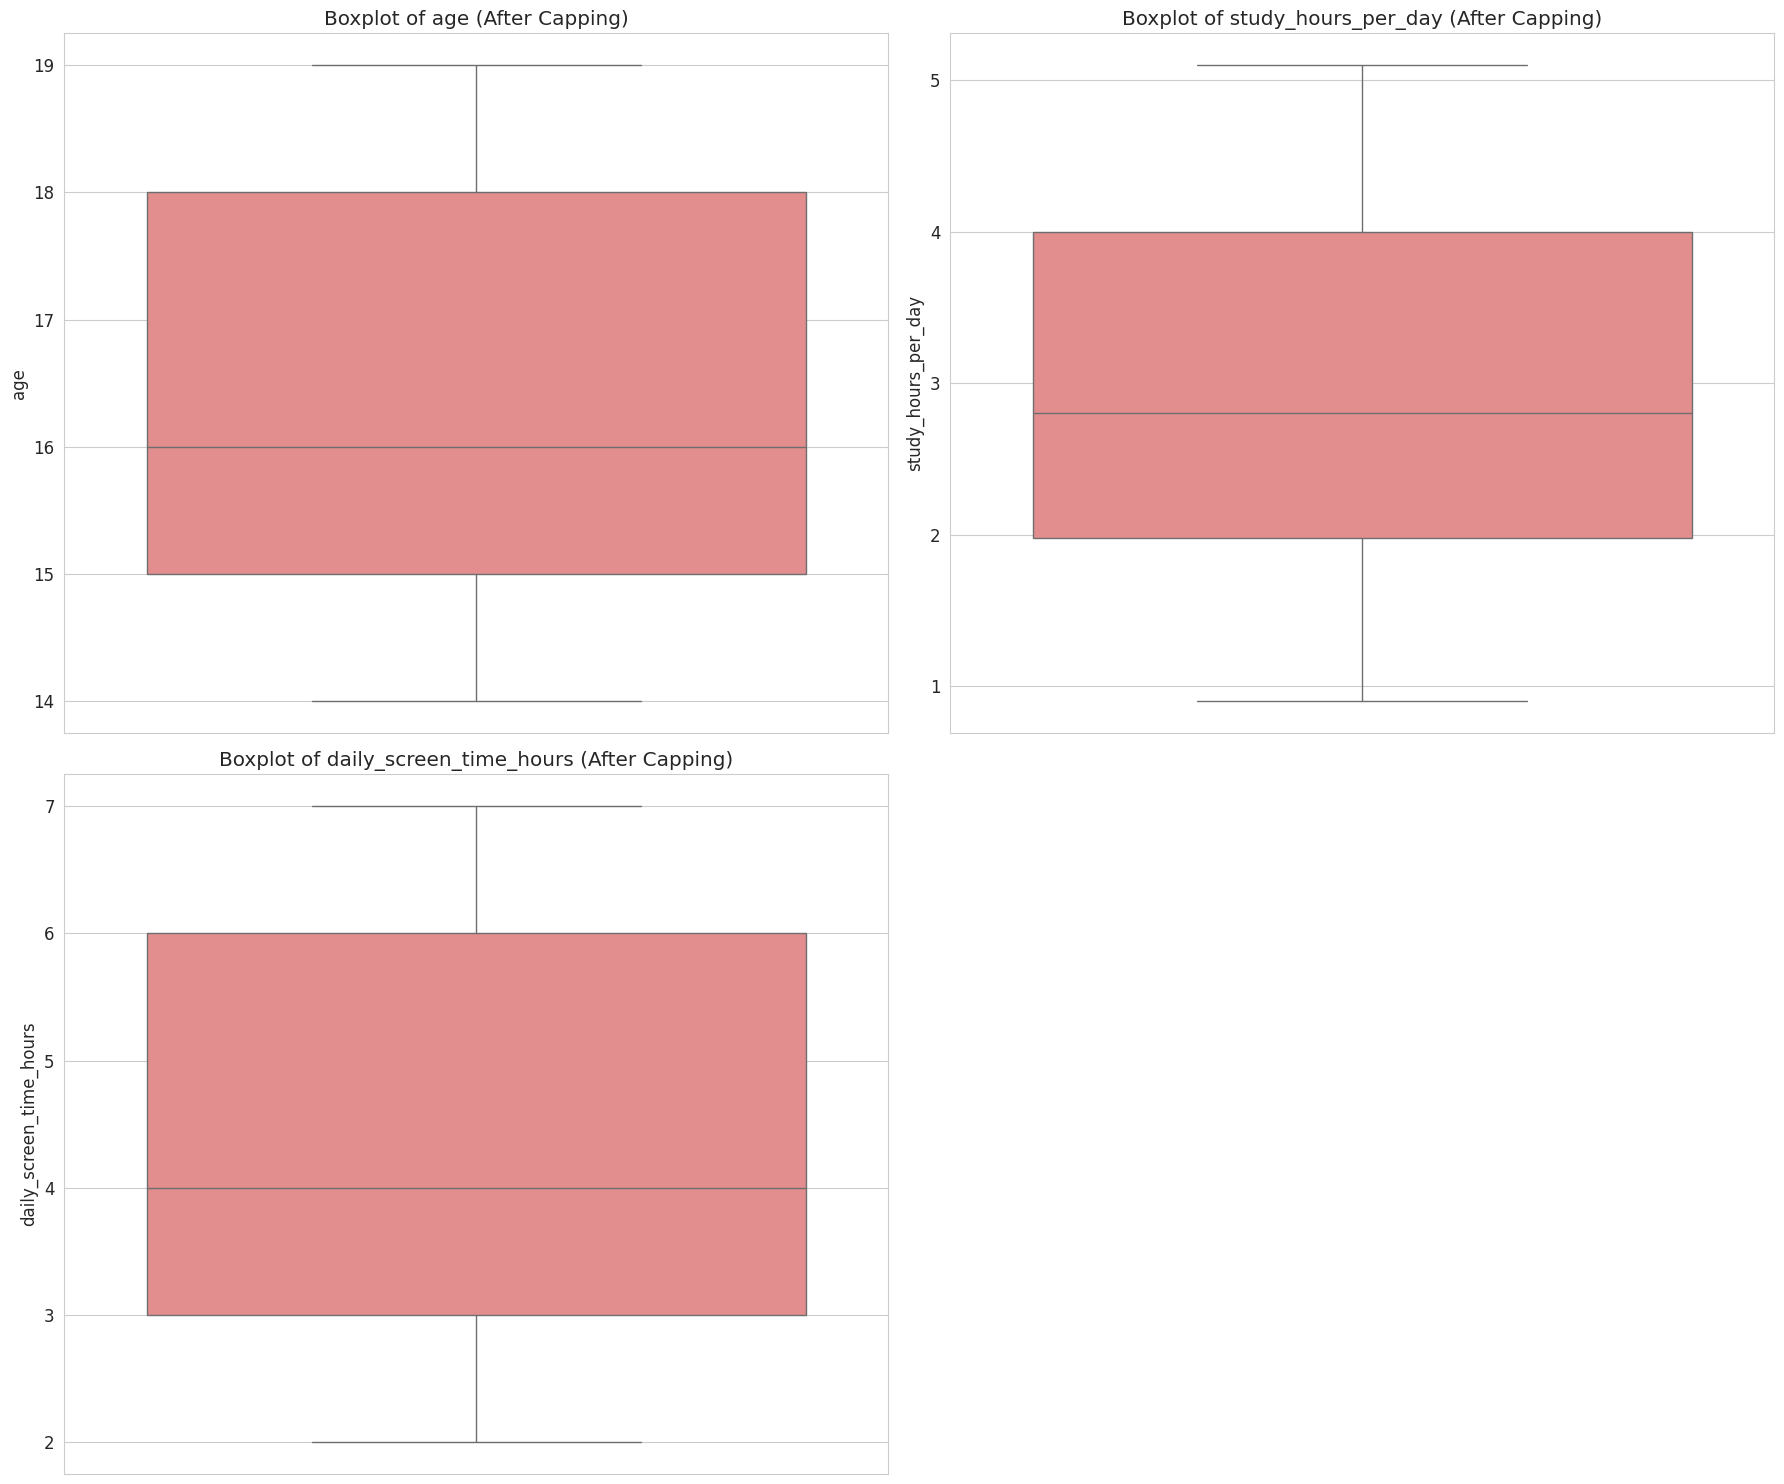

In [30]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    print(f"Outliers in '{column}' capped using IQR method.")
    return df

# Apply outlier capping to numerical columns (excluding grades which are usually bounded)
# We'll apply to 'age', 'study_hours_per_day', 'daily_screen_time_hours'

columns_to_cap = ['age', 'study_hours_per_day', 'daily_screen_time_hours']
for col in columns_to_cap:
    df = cap_outliers_iqr(df.copy(), col)

print("Outlier capping completed for specified numerical columns.")

# Verify by re-plotting boxplots
plt.figure(figsize=(18, 15))
for i, col in enumerate(columns_to_cap):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col} (After Capping)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## 25. Encode Categorical Variables

Categorical variables need to be converted into a numerical format for machine learning models. We will use:
- **Label Encoding** for binary categorical columns.
- **One-Hot Encoding** for multi-category nominal columns.

First, we identify binary and multi-category columns.

In [31]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Separate binary and multi-category columns
binary_cols = []
multi_category_cols = []

for col in categorical_cols:
    if df[col].nunique() <= 2:
        binary_cols.append(col)
    else:
        multi_category_cols.append(col)

print(f"Binary categorical columns: {binary_cols}")
print(f"Multi-category categorical columns: {multi_category_cols}")

# Apply Label Encoding for binary columns
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"'{col}' encoded with LabelEncoder. Mappings: {list(le.classes_)} -> {list(range(len(le.classes_)))}")

# Apply One-Hot Encoding for multi-category columns
# Ensure 'education_level' is handled first if it's considered ordinal but not handled as such
# For simplicity, treating all multi-category as nominal for OHE
if multi_category_cols:
    print("\nApplying One-Hot Encoding...")
    df = pd.get_dummies(df, columns=multi_category_cols, drop_first=True, dtype=int)
    print("One-Hot Encoding completed.")

print("\nDataFrame after encoding categorical variables:")
print(df.head())

Binary categorical columns: ['education_level', 'uses_ai']
Multi-category categorical columns: ['ai_tools_used', 'purpose_of_ai']
'education_level' encoded with LabelEncoder. Mappings: ['college', 'school'] -> [0, 1]
'uses_ai' encoded with LabelEncoder. Mappings: ['No', 'Yes'] -> [0, 1]

Applying One-Hot Encoding...
One-Hot Encoding completed.

DataFrame after encoding categorical variables:
    age  education_level  study_hours_per_day  uses_ai  grades_before_ai  \
0  19.0                0                  1.4        0                62   
1  15.0                1                  3.9        1                56   
2  15.0                1                  1.9        1                75   
3  15.0                1                  2.8        0                55   
4  19.0                0                  2.7        0                59   

   grades_after_ai  daily_screen_time_hours  ai_tools_used_Copilot  \
0               62                      3.0                      0   
1       

## 26. Feature Scaling using StandardScaler

Feature scaling is crucial for many machine learning algorithms that are sensitive to the magnitude of input features. `StandardScaler` standardizes features by removing the mean and scaling to unit variance (z-score normalization).

In [32]:
# Identify numerical columns for scaling (excluding the target variable if it's numerical)
# 'grades_after_ai' is our target, so we exclude it from feature scaling
features_to_scale = df.drop(columns=['grades_after_ai']).select_dtypes(include=np.number).columns.tolist()

print(f"Features to be scaled: {features_to_scale}")

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the selected features
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

print("\nFeatures scaled using StandardScaler.")
print("DataFrame head after scaling:")
print(df.head())

Features to be scaled: ['age', 'education_level', 'study_hours_per_day', 'uses_ai', 'grades_before_ai', 'daily_screen_time_hours', 'ai_tools_used_Copilot', 'ai_tools_used_Gemini', 'purpose_of_ai_Homework', 'purpose_of_ai_Research']

Features scaled using StandardScaler.
DataFrame head after scaling:
        age  education_level  study_hours_per_day   uses_ai  grades_before_ai  \
0  1.481632        -1.040833            -1.388585 -0.816497         -0.451275   
1 -0.879535         0.960769             0.798852  1.224745         -1.428765   
2 -0.879535         0.960769            -0.951098  1.224745          1.666621   
3 -0.879535         0.960769            -0.163620 -0.816497         -1.591680   
4  1.481632        -1.040833            -0.251118 -0.816497         -0.940020   

   grades_after_ai  daily_screen_time_hours  ai_tools_used_Copilot  \
0               62                -0.750915              -0.403473   
1               61                -1.311300               2.478479   
2 

## 27. Define Features (X) and Target (y)

Before splitting the data, we separate the features (independent variables, denoted as `X`) from the target variable (dependent variable, denoted as `y`). Our target variable is `Grades_After_AI`.

In [33]:
# Define features (X) and target (y)
X = df.drop('grades_after_ai', axis=1) # All columns except the target
y = df['grades_after_ai'] # The target column

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nFirst 5 rows of X (features):")
print(X.head())

print("\nFirst 5 values of y (target):")
print(y.head())

Features (X) shape: (300, 10)
Target (y) shape: (300,)

First 5 rows of X (features):
        age  education_level  study_hours_per_day   uses_ai  grades_before_ai  \
0  1.481632        -1.040833            -1.388585 -0.816497         -0.451275   
1 -0.879535         0.960769             0.798852  1.224745         -1.428765   
2 -0.879535         0.960769            -0.951098  1.224745          1.666621   
3 -0.879535         0.960769            -0.163620 -0.816497         -1.591680   
4  1.481632        -1.040833            -0.251118 -0.816497         -0.940020   

   daily_screen_time_hours  ai_tools_used_Copilot  ai_tools_used_Gemini  \
0                -0.750915              -0.403473             -0.386556   
1                -1.311300               2.478479             -0.386556   
2                 0.369854               2.478479             -0.386556   
3                -0.750915              -0.403473             -0.386556   
4                -0.750915              -0.403473   

## 28. Train-Test Split

The dataset is split into training and testing sets to evaluate the model's performance on unseen data. An 80% training and 20% testing split is used, with `random_state` set for reproducibility.

In [34]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (240, 10)
X_test shape: (60, 10)
y_train shape: (240,)
y_test shape: (60,)


## 29. Save the Cleaned Dataset

After all preprocessing steps, the cleaned and transformed dataset (or at least the `X_train`, `X_test`, `y_train`, `y_test` splits) is saved. For this notebook, we will save the full preprocessed `X` and `y` separately, or as a combined dataframe if preferred for model training notebooks.

In [35]:
# Save the preprocessed features and target to CSV files
# For clarity, we'll save the full processed DataFrame before split, and also the splits.
processed_df = pd.concat([X, y], axis=1)
processed_df.to_csv('students_ai_usage_processed.csv', index=False)
print("Full processed dataset saved to 'students_ai_usage_processed.csv'.")

X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Train and test sets (X_train, X_test, y_train, y_test) saved as CSV files.")

Full processed dataset saved to 'students_ai_usage_processed.csv'.
Train and test sets (X_train, X_test, y_train, y_test) saved as CSV files.


## 30. Display the Final Processed Dataset

To ensure the preprocessing steps were successful, we display the head of the final processed DataFrame. This shows the cleaned, encoded, and scaled features ready for model training.

In [36]:
# Display the first 5 rows of the final processed DataFrame
print("First 5 rows of the final processed dataset:")
print(processed_df.head())

First 5 rows of the final processed dataset:
        age  education_level  study_hours_per_day   uses_ai  grades_before_ai  \
0  1.481632        -1.040833            -1.388585 -0.816497         -0.451275   
1 -0.879535         0.960769             0.798852  1.224745         -1.428765   
2 -0.879535         0.960769            -0.951098  1.224745          1.666621   
3 -0.879535         0.960769            -0.163620 -0.816497         -1.591680   
4  1.481632        -1.040833            -0.251118 -0.816497         -0.940020   

   daily_screen_time_hours  ai_tools_used_Copilot  ai_tools_used_Gemini  \
0                -0.750915              -0.403473             -0.386556   
1                -1.311300               2.478479             -0.386556   
2                 0.369854               2.478479             -0.386556   
3                -0.750915              -0.403473             -0.386556   
4                -0.750915              -0.403473             -0.386556   

   purpose_of_ai_

## 31. Summary of Preprocessing Steps

This notebook meticulously covered all essential data preprocessing steps to prepare the `students_ai_usage` dataset for machine learning model training. The key steps performed include:

1.  **Project Setup & Overview**: Defined the project title, overview, and imported necessary libraries.
2.  **Data Loading & Initial Inspection**: Loaded the dataset and performed initial checks such as displaying first/last records, checking shape, info, data types, and column names.
3.  **Statistical Summary**: Gained insights into the central tendency and dispersion of both numerical and categorical features.
4.  **Missing Value Handling**: Identified and imputed missing values in 'AI_Tools_Used' and 'Purpose_of_AI' with 'None'.
5.  **Duplicate Removal**: Detected and removed any duplicate rows to ensure data uniqueness.
6.  **Exploratory Data Analysis (EDA)**: Visualized distributions of numerical and categorical variables, as well as the target variable (`Grades_After_AI`).
7.  **Correlation Analysis**: Examined linear relationships between numerical features using a heatmap.
8.  **Relationship Analysis**: Investigated the relationship between `Grades_After_AI` and key features like `Grades_Before_AI`, `Study_Hours_Per_Day`, `Daily_Screen_Time_Hours`, `Uses_AI`, `AI_Tools_Used`, and `Purpose_of_AI`.
9.  **Outlier Detection & Handling**: Identified outliers using boxplots and capped them using the IQR method for `age`, `study_hours_per_day`, and `daily_screen_time_hours`.
10. **Categorical Encoding**: Applied Label Encoding to binary columns and One-Hot Encoding to multi-category nominal columns.
11. **Feature Scaling**: Standardized numerical features using `StandardScaler` to bring them to a comparable scale.
12. **Features and Target Definition**: Separated the dataset into features (`X`) and the target variable (`y`).
13. **Train-Test Split**: Divided the data into training (80%) and testing (20%) sets for robust model evaluation.
14. **Dataset Saving**: Saved the fully preprocessed dataset and the split training/testing sets to CSV files for future use in model training.

This comprehensive preprocessing ensures that the data is clean, well-structured, and optimized for building high-performing regression models to predict student exam scores after AI tool usage.